In [2]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_recall_curve, auc

from imblearn.over_sampling import SMOTE

In [3]:
df = pd.read_csv("fraud_smote.csv")

In [5]:
print(df["Fraud"].value_counts())

Fraud
0    110
1     10
Name: count, dtype: int64


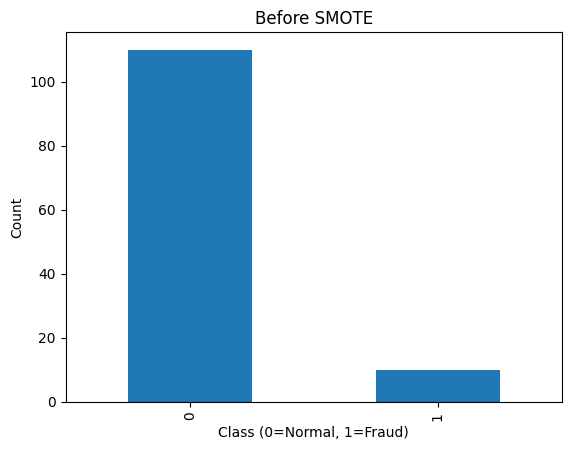

In [7]:
df["Fraud"].value_counts().plot(kind='bar')
plt.title("Before SMOTE")
plt.xlabel("Class (0=Normal, 1=Fraud)")
plt.ylabel("Count")
plt.show()

In [10]:
X = df.drop("Fraud", axis=1)
y = df["Fraud"]

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [11]:
model_before = LogisticRegression(max_iter=1000)
model_before.fit(X_train, y_train)

y_prob_before = model_before.predict_proba(X_test)[:, 1]

In [12]:
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

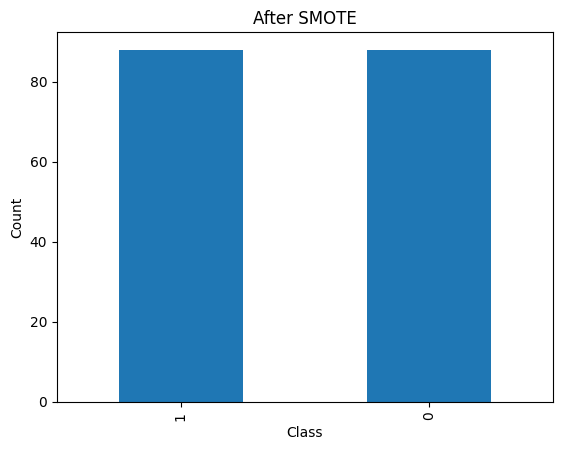

In [14]:
pd.Series(y_train_smote).value_counts().plot(kind='bar')
plt.title("After SMOTE")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

In [20]:
model_after = LogisticRegression(max_iter=1000)
model_after.fit(X_train_smote, y_train_smote)

y_prob_after = model_after.predict_proba(X_test)[:, 1]
precision_before, recall_before, _ = precision_recall_curve(y_test, y_prob_before)
precision_after, recall_after, _ = precision_recall_curve(y_test, y_prob_after) 
print("AUC Before SMOTE:", auc(recall_before, precision_before))
print("AUC After SMOTE:", auc(recall_after, precision_after))

AUC Before SMOTE: 0.059480676328502416
AUC After SMOTE: 0.06295289855072464


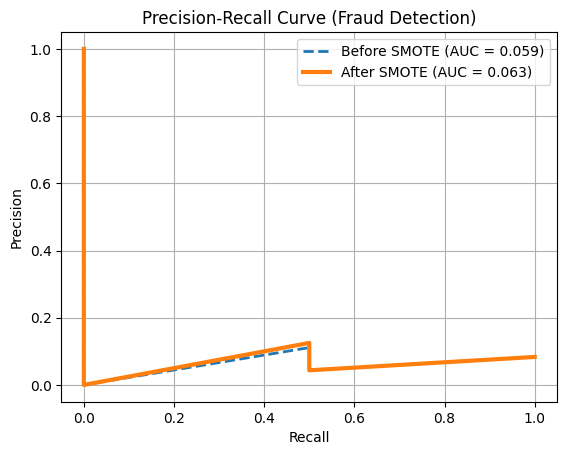

In [16]:
precision_b, recall_b, _ = precision_recall_curve(y_test, y_prob_before)
precision_a, recall_a, _ = precision_recall_curve(y_test, y_prob_after)

auc_b = auc(recall_b, precision_b)
auc_a = auc(recall_a, precision_a)

plt.figure()

plt.plot(recall_b, precision_b, linestyle='--', linewidth=2,
         label=f"Before SMOTE (AUC = {auc_b:.3f})")

plt.plot(recall_a, precision_a, linestyle='-', linewidth=3,
         label=f"After SMOTE (AUC = {auc_a:.3f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve (Fraud Detection)")

plt.legend()
plt.grid(True)

plt.show()